In [1]:
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
def load_data(startdate):

    startdate_dt = datetime.strptime(startdate, '%Y-%m-%d')
    enddate_dt = startdate_dt + timedelta(days=11)
    enddate = enddate_dt.strftime('%Y-%m-%d')

    countries = ['DE', 'FR', 'IT', 'RO']

    c=0
    for country in countries:
        file_path = f'raw_metdesk/wind_{country}_eceps_{startdate}T00_{enddate}T00.csv'
        climate_path = f'raw_metdesk/climate_{country}_{startdate}_{enddate}.csv'
        
        # select the mean of eps
        data = pd.read_csv(file_path)
        data_eceps = data[data['member']== 'mean'].copy()
        data_eceps.drop(columns=['member'], inplace=True)

        climate_data = pd.read_csv(climate_path)

        # column dtg as datetime
        data_eceps['dtg'] = pd.to_datetime(data_eceps['dtg'], format='%Y-%m-%dT%H:%M:%SZ')
        climate_data['dtg'] = pd.to_datetime(climate_data['dtg'], format='%Y-%m-%dT%H:%M:%SZ')
        # rename value by the country
        data_eceps.rename(columns={'value': f'{country}'}, inplace=True)
        climate_data.rename(columns={'value': f'climate_{country}'}, inplace=True)
        # only select full hours of dtg
        data_eceps = data_eceps[data_eceps['dtg'].dt.minute == 0].copy()
        climate_data = climate_data[climate_data['dtg'].dt.minute == 0].copy()
        # set dtg as index
        data_eceps.set_index('dtg', inplace=True)
        climate_data.set_index('dtg', inplace=True)

        # merge data_eceps and climate_data on dtg
        data_eceps = data_eceps.merge(climate_data, left_index=True, right_index=True, how='outer')

        if c == 0:
            data_all = data_eceps
        else:
            data_all = pd.concat([data_all, data_eceps], axis=1)
        c += 1
   
    return data_all

In [3]:
startdate=datetime.today().strftime('%Y-%m-%d')
eceps = load_data(startdate)

In [4]:
eceps

,DE,climate_DE,FR,climate_FR,IT,climate_IT,RO,climate_RO
dtg,,,,,,,,
2025-07-30 00:00:00,14989.72,10821.59,2747.44,3139.16,3988.41,1426.54,736.28,304.81
2025-07-30 01:00:00,15174.88,10821.90,2713.83,3138.46,4055.98,1426.09,697.97,304.68
2025-07-30 02:00:00,15360.04,10821.07,2680.21,3137.55,4123.56,1425.74,659.65,304.61
2025-07-30 03:00:00,15545.20,10820.31,2646.60,3136.57,4191.13,1425.15,621.34,304.54
2025-07-30 04:00:00,15282.92,10819.48,2440.25,3135.33,3921.03,1424.73,599.60,304.43
...,...,...,...,...,...,...,...,...
2025-08-09 20:00:00,7558.31,11120.21,4312.65,3114.73,1935.61,1320.63,533.84,300.45
2025-08-09 21:00:00,7653.27,11123.80,4483.51,3115.16,1894.08,1320.28,513.09,300.44
2025-08-09 22:00:00,7748.22,11127.16,4654.37,3115.95,1852.55,1319.92,492.34,300.49


In [5]:
def plot_data(data):
    """    Plot the data for all countries on different subplots."""

    fig, ax = plt.subplots(4, 1, figsize=(10, 10), sharex=True)
    colors = {'DE': 'orange', 'FR': 'blue', 'IT': 'red', 'RO': 'maroon'}

    for i, country in enumerate(['DE', 'FR', 'IT', 'RO']):
        ax[i].plot(data.index, data[country]/1000, color=colors[country], label=country)
        ax[i].plot(data.index, data[f'climate_{country}']/1000, color=colors[country], linestyle='--', label=f'Climate {country}')
        ax[i].legend()
        ax[i].set_ylabel('Wind Generation (GW)')

        # vertical bar for monday
        for j in range(0, len(data.index), 24):
            if data.index[j].weekday() == 0:
                ax[i].axvline(x=data.index[j], color='gray', linestyle='-', linewidth=0.5)
                # add week number on the right side
                xpad= 0.02
                ax[i].text(data.index[j] + timedelta(hours=1), ax[i].get_ylim()[1]*0.9, f'Week {data.index[j].isocalendar()[1]}',
                           horizontalalignment='left', verticalalignment='center', fontsize=8, color='gray')
                break            

    plt.suptitle(f'EC EPS {data.index[0].strftime("%Y-%m-%d")} 00Z')
    plt.tight_layout()


    plt.show()
        

    

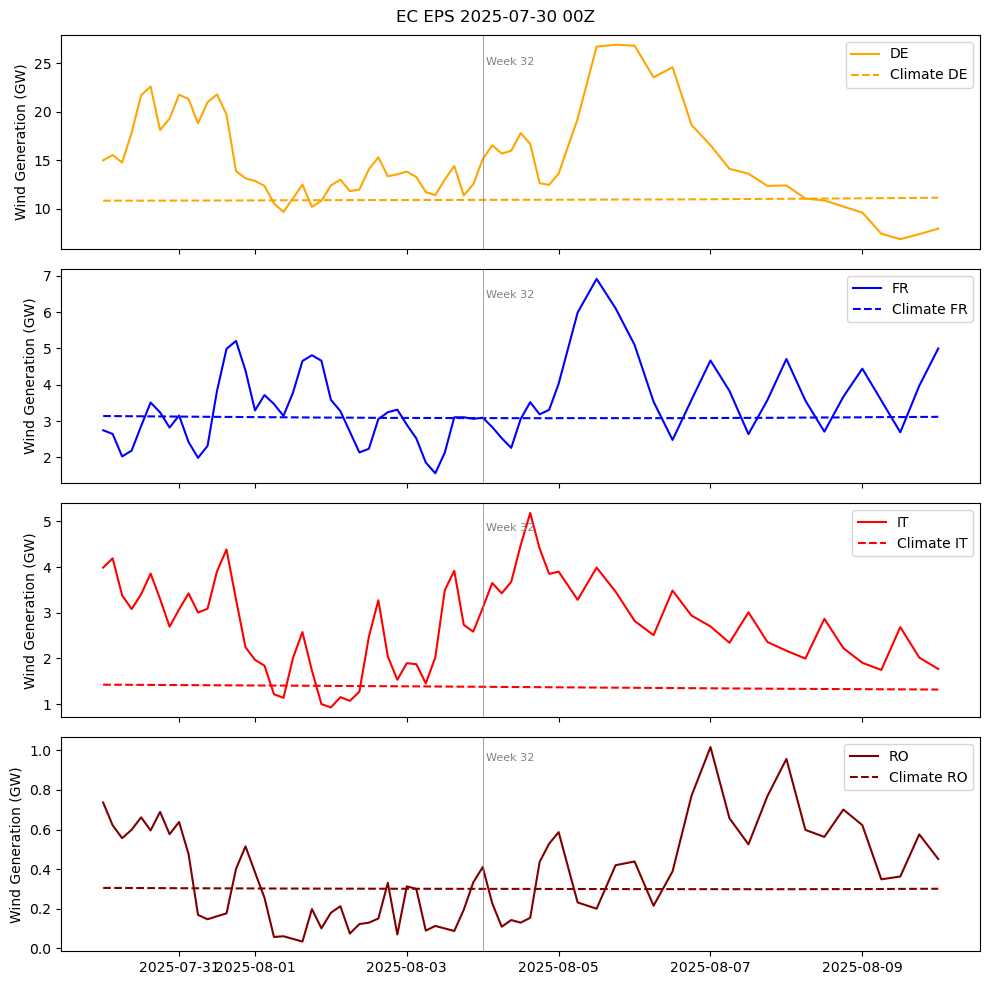

In [6]:
plot_data(eceps)